# DEMAND FORECASTING & INVENTORY DECISION PROTOTYPE

IMPORT LIBRARIES

In [41]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore the 'feature names' warning for a cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

CONFIGURATION & REPRODUCIBILITY

In [42]:
np.random.seed(42)  
n_skus, n_days = 25, 730
dates = pd.date_range(start="2022-01-01", periods=n_days, freq="D")

SYNTHETIC DATA GENERATION

In [43]:
records = []
for sku in range(n_skus):
    base_demand = np.random.uniform(20, 100)
    trend = np.random.uniform(-0.01, 0.02)
    for t, date in enumerate(dates):
        seasonality = 10 * np.sin(2 * np.pi * (t % 7) / 7)
        noise = np.random.normal(0, 5)
        promotion = np.random.binomial(1, 0.05)   
        disruption = np.random.binomial(1, 0.03)  
        event = np.random.binomial(1, 0.04)       
        demand = (base_demand + trend * t + seasonality + 
                  15 * promotion - 20 * disruption + 10 * event + noise)
        records.append([date, sku, max(0, demand), promotion, disruption, event])

df = pd.DataFrame(records, columns=["date", "sku", "demand", "promotion", "disruption", "event"])

FEATURE ENGINEERING

In [44]:
df = df.sort_values(["sku", "date"])
for lag in [1, 7]:
    df[f"lag_{lag}"] = df.groupby("sku")["demand"].shift(lag)
df["rolling_mean_7"] = df.groupby("sku")["demand"].shift(1).rolling(7).mean()
df["rolling_std_7"] = df.groupby("sku")["demand"].shift(1).rolling(7).std()
df = df.dropna()

VALIDATION STRATEGY

In [45]:
split_date = df["date"].quantile(0.8)
train, test = df[df["date"] <= split_date].copy(), df[df["date"] > split_date].copy()
features_base = ["lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]
features_full = features_base + ["promotion", "disruption", "event"]

MODEL TRAINING

In [46]:
model_base = LinearRegression().fit(train[features_base], train["demand"])
model_full = LinearRegression().fit(train[features_full], train["demand"])
test["pred_base"] = model_base.predict(test[features_base])
test["pred_full"] = model_full.predict(test[features_full])

SKU COMPARISON SELECTION

In [47]:
test["signals"] = test["promotion"] + test["disruption"] + test["event"]
signal_sums = test.groupby("sku")["signals"].sum()
peaceful_sku = signal_sums.idxmin() # SKU 2 usually
active_sku = signal_sums.idxmax()   # SKU 3 usually

SCENARIO SIMULATION LOGIC

In [48]:
def simulate_scenarios(base_row, model):
    results = []
    # Convert base_row to a DataFrame with feature names to avoid warnings
    for mult in [0.8, 1.0, 1.2]:
        for p, d in [(0,0), (1,0), (0,1), (1,1)]:
            case = pd.DataFrame([base_row[features_full].values], columns=features_full)
            case["promotion"], case["disruption"] = p, d
            pred = model.predict(case)[0]
            results.append({"multiplier": mult, "promotion": p, "disruption": d, "avg_demand": pred * mult})
    return pd.DataFrame(results)

RESULTS DEMONSTRATION & FINAL REPORTING

In [49]:
# --- TABLE 1: GLOBAL MODEL PERFORMANCE ---
mae_base = mean_absolute_error(test["demand"], test["pred_base"])
rmse_base = np.sqrt(mean_squared_error(test["demand"], test["pred_base"]))
mae_full = mean_absolute_error(test["demand"], test["pred_full"])
rmse_full = np.sqrt(mean_squared_error(test["demand"], test["pred_full"]))

print(f"{'='*50}\n1. MODEL PERFORMANCE\n{'='*50}")
print(f"Baseline  -> MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}")
print(f"Full Model-> MAE: {mae_full:.2f}, RMSE: {rmse_full:.2f}")
print(f"MAE Improvement:  {((mae_base-mae_full)/mae_base)*100:.2f}%")
print(f"RMSE Improvement: {((rmse_base-rmse_full)/rmse_base)*100:.2f}%")

# --- TABLE 2: VARIANCE REDUCTION ---
var_base = np.var(test["demand"] - test["pred_base"])
var_full = np.var(test["demand"] - test["pred_full"])
print(f"\n{'='*50}\n2. VARIANCE REDUCTION\n{'='*50}")
print(f"Baseline Var: {var_base:.2f} | Full Model Var: {var_full:.2f}")
print(f"Total Noise Reduction: {((var_base-var_full)/var_base)*100:.2f}%")

# --- TABLE 3: FEATURE IMPACT (COEFFICIENTS) ---
print(f"\n{'='*50}\n3. FEATURE IMPACT (WEIGHTS)\n{'='*50}")
coef_df = pd.DataFrame({"feature": features_full, "coef": model_full.coef_}).sort_values(by="coef", key=abs, ascending=False)
print(coef_df)

# --- TABLE 4: HIGH-UNCERTAINTY SKUs ---
print(f"\n{'='*50}\n4. HIGH-UNCERTAINTY SKUs (TOP ERRORS)\n{'='*50}")
test["error"] = abs(test["demand"] - test["pred_full"])
print(test.groupby("sku")["error"].mean().sort_values(ascending=False).head())

# --- TABLE 5: SCENARIO RESULTS (FOR ACTIVE SKU) ---
print(f"\n{'='*50}\n5. SCENARIO ANALYSIS (ACTIVE SKU {active_sku})\n{'='*50}")
active_sample = test[test["sku"] == active_sku].iloc[-1]
scenario_results = simulate_scenarios(active_sample, model_full)
print(scenario_results)

# --- TABLE 6: COMPARATIVE SAFETY STOCK ---
print(f"\n{'='*50}\n6. SAFETY STOCK COMPARISON (PEACEFUL VS ACTIVE)\n{'='*50}")
z_levels = {"90% Service": 1.28, "95% Service": 1.65, "99% Service": 2.33}
safety_data = []
for s_id in [peaceful_sku, active_sku]:
    sigma = np.std(df[df["sku"] == s_id]["demand"])
    name = f"SKU {s_id} ({'Active' if s_id == active_sku else 'Peaceful'})"
    for sl, z in z_levels.items():
        ss = z * sigma * np.sqrt(7) # 7-day lead time
        safety_data.append({"SKU": name, "Level": sl, "Stock": round(ss, 2)})
print(pd.DataFrame(safety_data).pivot(index="Level", columns="SKU", values="Stock"))

1. MODEL PERFORMANCE
Baseline  -> MAE: 6.72, RMSE: 8.81
Full Model-> MAE: 5.68, RMSE: 7.16
MAE Improvement:  15.40%
RMSE Improvement: 18.72%

2. VARIANCE REDUCTION
Baseline Var: 77.60 | Full Model Var: 51.24
Total Noise Reduction: 33.97%

3. FEATURE IMPACT (WEIGHTS)
          feature       coef
5      disruption -20.090371
4       promotion  14.492357
6           event  10.286007
1           lag_7   0.475327
2  rolling_mean_7   0.298572
0           lag_1   0.212158
3   rolling_std_7   0.039911

4. HIGH-UNCERTAINTY SKUs (TOP ERRORS)
sku
7     6.233773
9     6.181504
17    6.048237
18    6.025433
21    6.022568
Name: error, dtype: float64

5. SCENARIO ANALYSIS (ACTIVE SKU 3)
    multiplier  promotion  disruption  avg_demand
0          0.8          0           0   85.366878
1          0.8          1           0   96.960764
2          0.8          0           1   69.294581
3          0.8          1           1   80.888467
4          1.0          0           0  106.708598
5          1.0    

VISUALIZATION

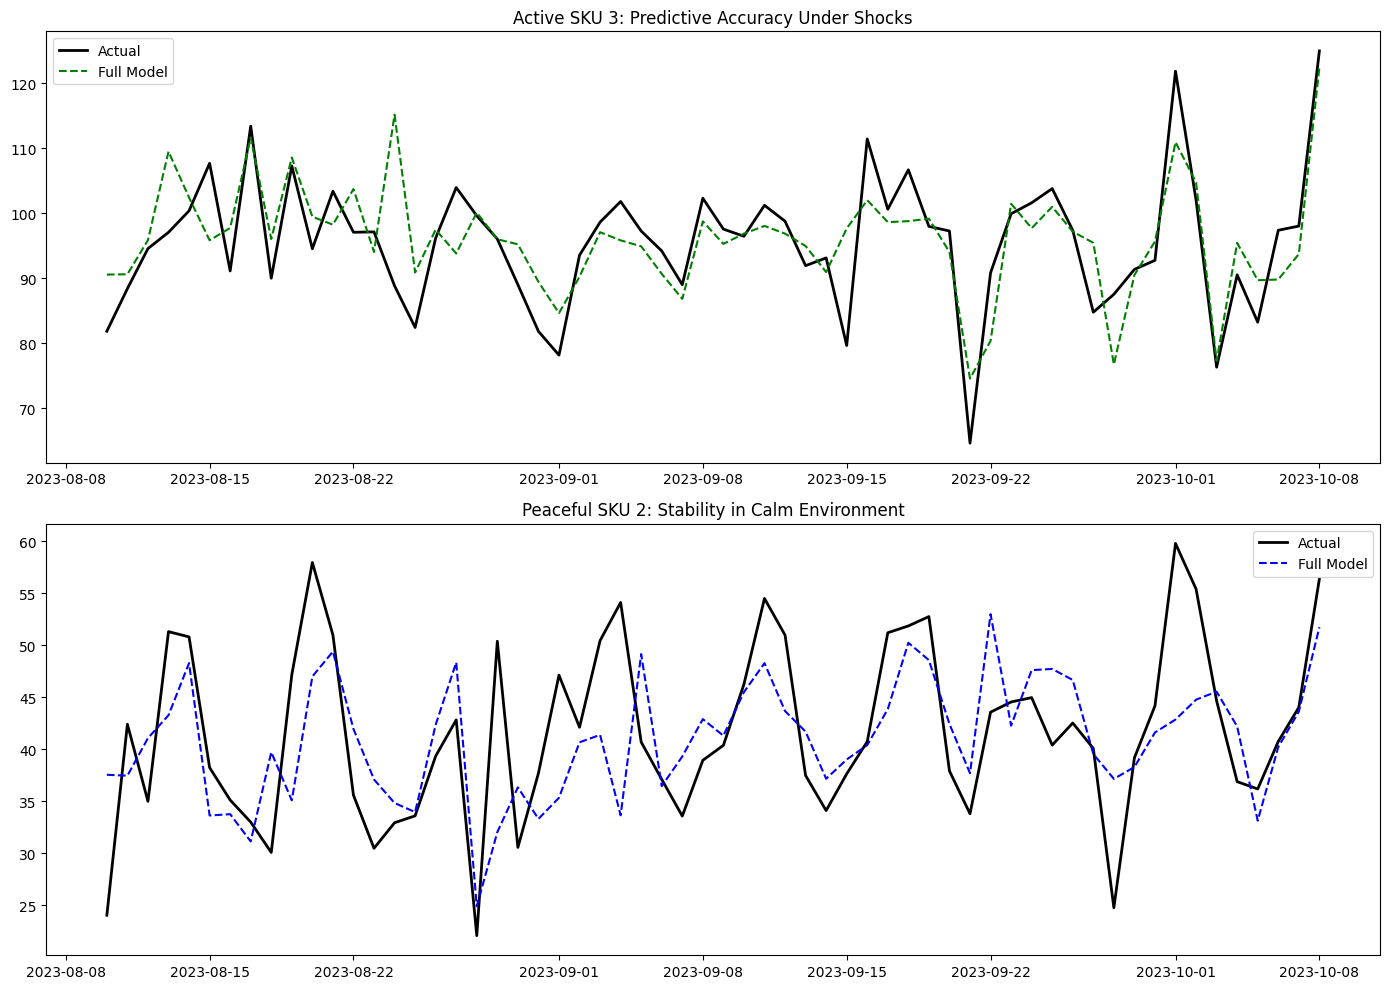

/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/380759536.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="coef", y="feature", palette="magma")


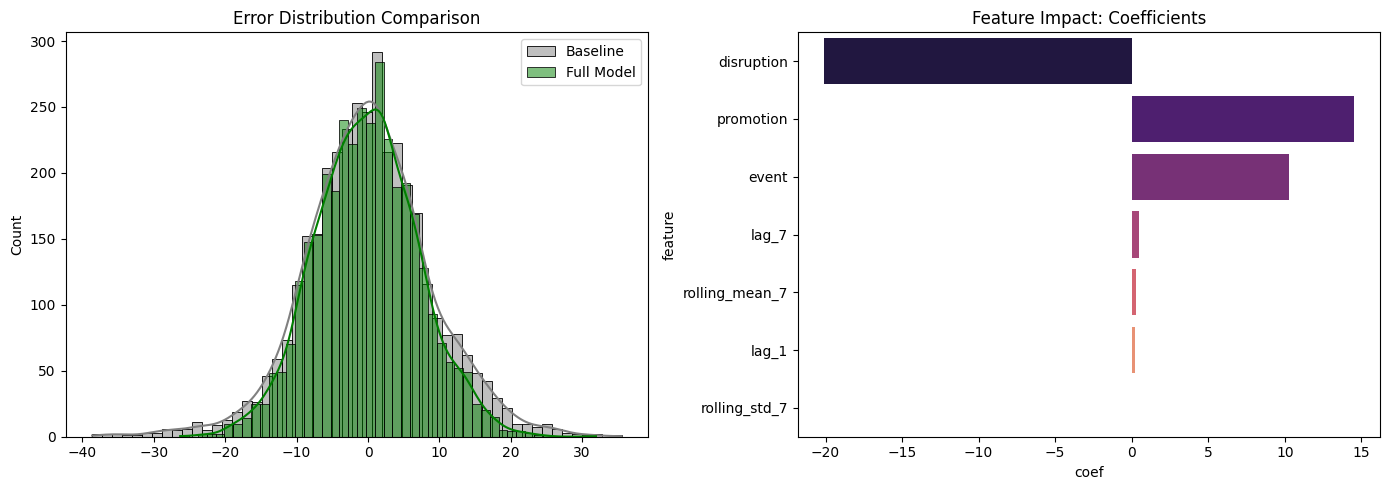

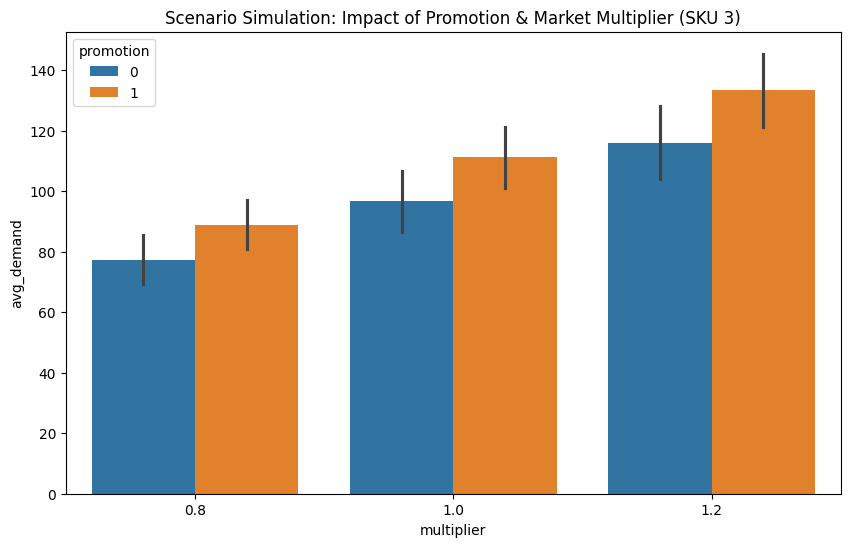

In [50]:
# 9.1 Forecast Accuracy Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
active_data = test[test["sku"] == active_sku].head(60)
ax1.plot(active_data["date"], active_data["demand"], label="Actual", color="black", linewidth=2)
ax1.plot(active_data["date"], active_data["pred_full"], label="Full Model", color="green", linestyle="--")
ax1.set_title(f"Active SKU {active_sku}: Predictive Accuracy Under Shocks")
ax1.legend()

peaceful_data = test[test["sku"] == peaceful_sku].head(60)
ax2.plot(peaceful_data["date"], peaceful_data["demand"], label="Actual", color="black", linewidth=2)
ax2.plot(peaceful_data["date"], peaceful_data["pred_full"], label="Full Model", color="blue", linestyle="--")
ax2.set_title(f"Peaceful SKU {peaceful_sku}: Stability in Calm Environment")
ax2.legend()
plt.tight_layout()
plt.show()

# 9.2 Error Dist & Feature Importance
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(test["demand"] - test["pred_base"], label="Baseline", color="gray", kde=True, alpha=0.5)
sns.histplot(test["demand"] - test["pred_full"], label="Full Model", color="green", kde=True, alpha=0.5)
plt.title("Error Distribution Comparison")
plt.legend()

plt.subplot(1, 2, 2)
sns.barplot(data=coef_df, x="coef", y="feature", palette="magma")
plt.title("Feature Impact: Coefficients")
plt.tight_layout()
plt.show()

# 9.3 Scenario Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=scenario_results, x="multiplier", y="avg_demand", hue="promotion")
plt.title(f"Scenario Simulation: Impact of Promotion & Market Multiplier (SKU {active_sku})")
plt.show()